In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
rfm = pd.read_csv("customer_clv_data.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment,Cluster,Segment,Avg_Order_Value,Customer_Lifetime,CLV,CLV_segment
0,12347.0,7,1,711.79,3,1,5,9,315,0,Champions,711.79,1,711.79,High CLV
1,12370.0,1,1,1590.82,5,1,5,11,515,0,Champions,1590.82,1,1590.82,High CLV
2,12386.0,7,1,258.90,3,1,2,6,312,0,Champions,258.90,1,258.90,Medium CLV
3,12395.0,11,1,346.10,2,1,3,6,213,2,Potential Loyalists,346.10,1,346.10,Medium CLV
4,12427.0,12,1,303.50,2,1,3,6,213,2,Potential Loyalists,303.50,1,303.50,Medium CLV


In [ ]:
total_revenue = rfm['Monetary'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 411589.49


In [ ]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

segment_revenue

,Monetary
Segment,
Champions,165597.18
Lost Customers,100963.46
Potential Loyalists,90802.21
At Risk,45179.39
Loyal Customers,9047.25


In [ ]:
segment_revenue_percent = (segment_revenue / total_revenue) * 100

segment_revenue_percent

,Monetary
Segment,
Champions,40.233578
Lost Customers,24.530136
Potential Loyalists,22.061353
At Risk,10.976808
Loyal Customers,2.198125


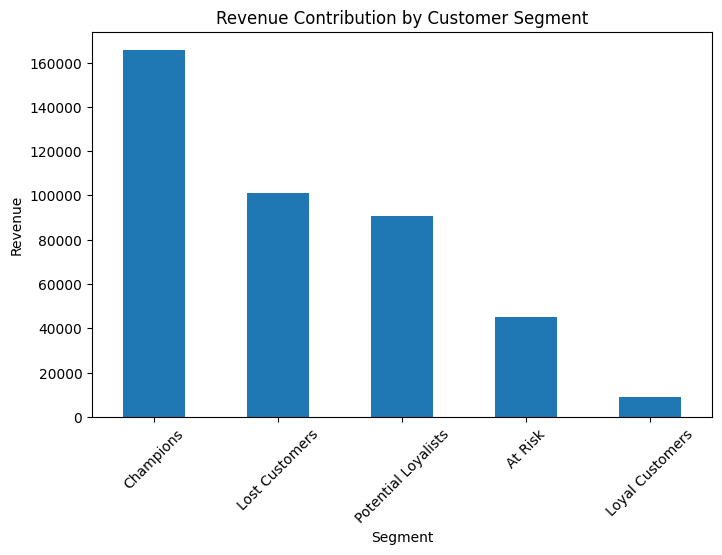

In [ ]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind='bar')

plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [ ]:
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False)

In [ ]:
rfm_sorted['cumulative_revenue'] = rfm_sorted['Monetary'].cumsum()

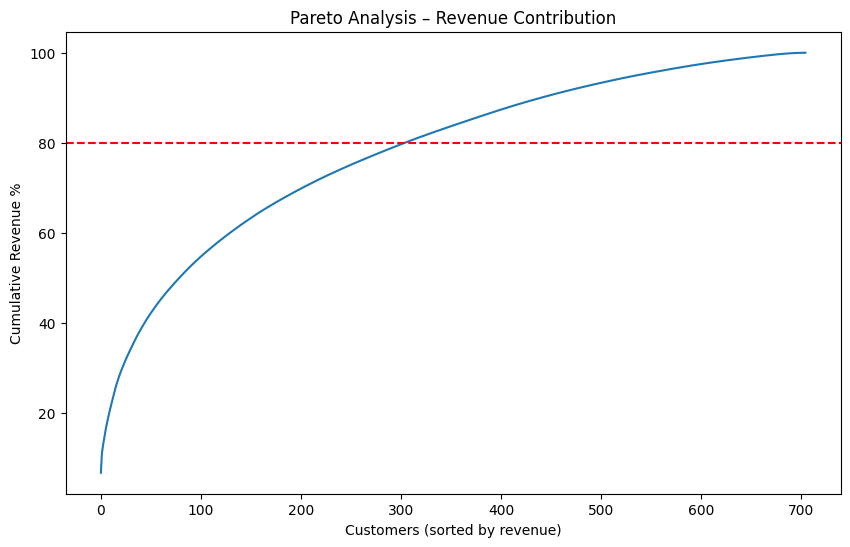

In [ ]:
plt.figure(figsize=(10,6))

rfm_sorted['cumulative_percent'] = (rfm_sorted['cumulative_revenue'] / total_revenue) * 100

plt.plot(rfm_sorted['cumulative_percent'].values)

plt.axhline(80, color='red', linestyle='--')

plt.title("Pareto Analysis – Revenue Contribution")
plt.xlabel("Customers (sorted by revenue)")
plt.ylabel("Cumulative Revenue %")

plt.show()

In [ ]:
top_20_percent = int(0.2 * len(rfm_sorted))

top_customers = rfm_sorted.head(top_20_percent)

top_customers

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment,Cluster,Segment,Avg_Order_Value,Customer_Lifetime,CLV,CLV_segment,cumulative_revenue,cumulative_percent
689,18102.0,6,4,27834.61,4,5,5,14,455,3,At Risk,6958.652500,4,27834.61,High CLV,27834.61,6.762712
288,15061.0,5,11,17344.78,4,5,5,14,455,3,At Risk,1576.798182,11,17344.78,High CLV,45179.39,10.976808
140,13777.0,6,9,6840.16,4,5,5,14,455,4,Lost Customers,760.017778,9,6840.16,High CLV,52019.55,12.638697
270,14911.0,5,9,5567.63,4,5,5,14,455,4,Lost Customers,618.625556,9,5567.63,High CLV,57587.18,13.991412
635,17850.0,12,34,5391.21,2,5,5,12,255,1,Loyal Customers,158.565000,34,5391.21,High CLV,62978.39,15.301263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,13269.0,1,2,662.17,5,4,5,14,545,0,Champions,331.085000,2,662.17,High CLV,251763.81,61.168668
210,14440.0,6,1,656.70,4,2,5,11,425,0,Champions,656.700000,1,656.70,High CLV,252420.51,61.328221
701,18229.0,7,2,653.20,3,5,5,13,355,0,Champions,326.600000,2,653.20,High CLV,253073.71,61.486922
104,13324.0,1,1,650.10,5,1,5,11,515,0,Champions,650.100000,1,650.10,High CLV,253723.81,61.644871


In [ ]:
top_customers['Monetary'].sum() / total_revenue * 100

np.float64(61.801366696705486)

In [ ]:
at_risk_customers = rfm[rfm['Segment'] == 'At Risk']

at_risk_customers.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment,Cluster,Segment,Avg_Order_Value,Customer_Lifetime,CLV,CLV_segment
288,15061.0,5,11,17344.78,4,5,5,14,455,3,At Risk,1576.798182,11,17344.78,High CLV
689,18102.0,6,4,27834.61,4,5,5,14,455,3,At Risk,6958.652500,4,27834.61,High CLV


In [ ]:
len(at_risk_customers)

2

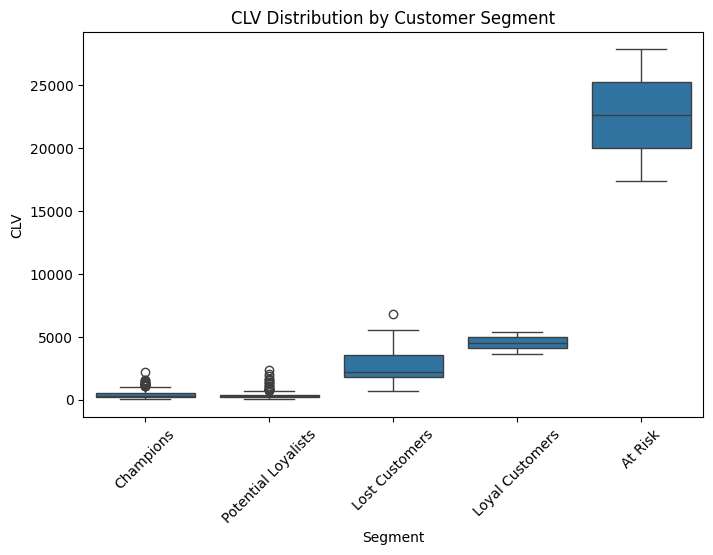

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=rfm, x='Segment', y='CLV')

plt.xticks(rotation=45)

plt.title("CLV Distribution by Customer Segment")

plt.show()

In [ ]:
rfm.to_csv("final_customer_analysis.csv", index=False)